### Plotting Simulated S&P 500 Closing Prices

Since real-time future data is not available, I'll simulate the S&P 500 closing prices based on your provided criteria (rise from 6800 to 7600 between January 1, 2026, and June 4, 2026) and then plot the simulated trend.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define the date range
start_date = '2026-01-01'
end_date = '2026-06-04'
date_range = pd.date_range(start=start_date, end=end_date, freq='B') # 'B' for business days

# Define start and end prices
start_price = 6800
end_price = 7600

# Generate a linear trend
linear_prices = np.linspace(start_price, end_price, len(date_range))

# Add some random noise to make it look more realistic
np.random.seed(42) # for reproducibility
noise = np.random.normal(0, 20, len(date_range)) # Mean 0, Std Dev 20
simulated_prices = linear_prices + noise

# Create a DataFrame
simulated_sp500_df = pd.DataFrame({
    'Date': date_range,
    'Closing Price': simulated_prices
})

# Display the first few rows of the simulated data
print("Simulated S&P 500 Data Head:")
display(simulated_sp500_df.head())

print("\nSimulated S&P 500 Data Tail:")
display(simulated_sp500_df.tail())

Simulated S&P 500 Data Head:


,Date,Closing Price
0,2026-01-01,6809.934283
1,2026-01-02,6804.507441
2,2026-01-05,6827.499225
3,2026-01-06,6852.278779
4,2026-01-07,6824.407842



Simulated S&P 500 Data Tail:


,Date,Closing Price
106,2026-05-29,7608.632809
107,2026-06-01,7581.673374
108,2026-06-02,7590.605553
109,2026-06-03,7591.238354
110,2026-06-04,7561.624576


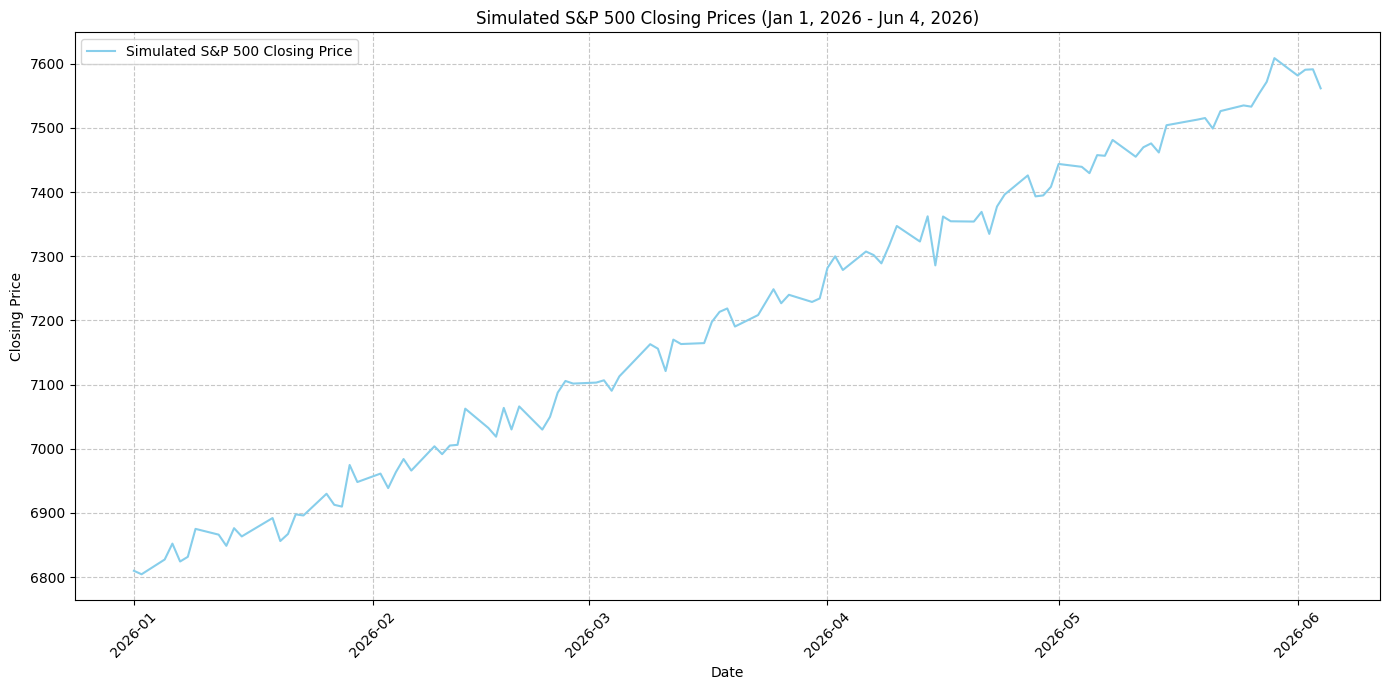

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(simulated_sp500_df['Date'], simulated_sp500_df['Closing Price'], label='Simulated S&P 500 Closing Price', color='skyblue')
plt.title('Simulated S&P 500 Closing Prices (Jan 1, 2026 - Jun 4, 2026)')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Plotting Profit/Loss for Long Call Option on SPY

Based on your request, I will calculate and plot the daily intrinsic value (P/L before premium) for a long call option with a strike price of 720, using the simulated S&P 500 data. As discussed, the SPY price is approximated as `S&P 500 Index / 10`, and we are assuming daily 'expiration' for the intrinsic value calculation.

In [ ]:
# Define option parameters
strike_price = 720

# Calculate approximate SPY price from simulated S&P 500 index
simulated_sp500_df['SPY Price'] = simulated_sp500_df['Closing Price'] / 10

# Calculate daily P/L (intrinsic value) for a long call option
# P/L = max(0, S - K) - Premium (premium is ignored here)
simulated_sp500_df['Daily P/L'] = np.maximum(0, simulated_sp500_df['SPY Price'] - strike_price)

print("Simulated SPY Price and Daily P/L Data Head:")
display(simulated_sp500_df.head())

print("\nSimulated SPY Price and Daily P/L Data Tail:")
display(simulated_sp500_df.tail())

Simulated SPY Price and Daily P/L Data Head:


,Date,Closing Price,SPY Price,Daily P/L
0,2026-01-01,6809.934283,680.993428,0.0
1,2026-01-02,6804.507441,680.450744,0.0
2,2026-01-05,6827.499225,682.749923,0.0
3,2026-01-06,6852.278779,685.227878,0.0
4,2026-01-07,6824.407842,682.440784,0.0



Simulated SPY Price and Daily P/L Data Tail:


,Date,Closing Price,SPY Price,Daily P/L
106,2026-05-29,7608.632809,760.863281,40.863281
107,2026-06-01,7581.673374,758.167337,38.167337
108,2026-06-02,7590.605553,759.060555,39.060555
109,2026-06-03,7591.238354,759.123835,39.123835
110,2026-06-04,7561.624576,756.162458,36.162458


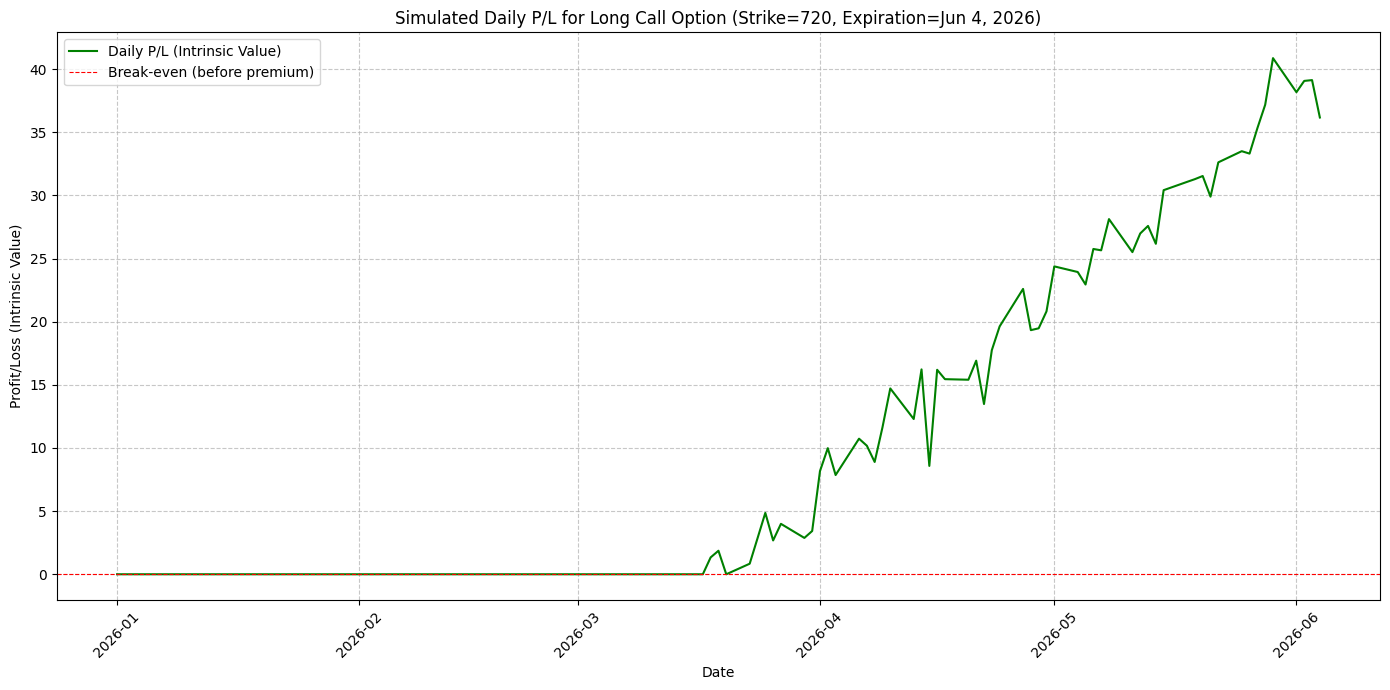

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(simulated_sp500_df['Date'], simulated_sp500_df['Daily P/L'], label='Daily P/L (Intrinsic Value)', color='green')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8, label='Break-even (before premium)')
plt.title(f'Simulated Daily P/L for Long Call Option (Strike={strike_price}, Expiration=Jun 4, 2026)')
plt.xlabel('Date')
plt.ylabel('Profit/Loss (Intrinsic Value)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Plotting Daily P/L for 1 Long Call Option Contract (Including Premium)

I will now calculate and plot the daily P/L for one long call option contract, taking into account an assumed premium. As discussed, I'm assuming a premium of $5.00 per share ($500 per contract).

In [ ]:
# Define premium per share and per contract
premium_per_share = 5.00  # Assumed premium for the OTM call option
premium_per_contract = premium_per_share * 100 # One contract is typically 100 shares

# Recalculate P/L for 1 contract, including the premium
# P/L = (max(0, S - K) * 100) - Premium Paid
simulated_sp500_df['P/L per Contract'] = (np.maximum(0, simulated_sp500_df['SPY Price'] - strike_price) * 100) - premium_per_contract

print("Simulated SPY Price and P/L per Contract Data Head:")
display(simulated_sp500_df[['Date', 'SPY Price', 'P/L per Contract']].head())

print("\nSimulated SPY Price and P/L per Contract Data Tail:")
display(simulated_sp500_df[['Date', 'SPY Price', 'P/L per Contract']].tail())

Simulated SPY Price and P/L per Contract Data Head:


,Date,SPY Price,P/L per Contract
0,2026-01-01,680.993428,-500.0
1,2026-01-02,680.450744,-500.0
2,2026-01-05,682.749923,-500.0
3,2026-01-06,685.227878,-500.0
4,2026-01-07,682.440784,-500.0



Simulated SPY Price and P/L per Contract Data Tail:


,Date,SPY Price,P/L per Contract
106,2026-05-29,760.863281,3586.328089
107,2026-06-01,758.167337,3316.733744
108,2026-06-02,759.060555,3406.055533
109,2026-06-03,759.123835,3412.383544
110,2026-06-04,756.162458,3116.245757


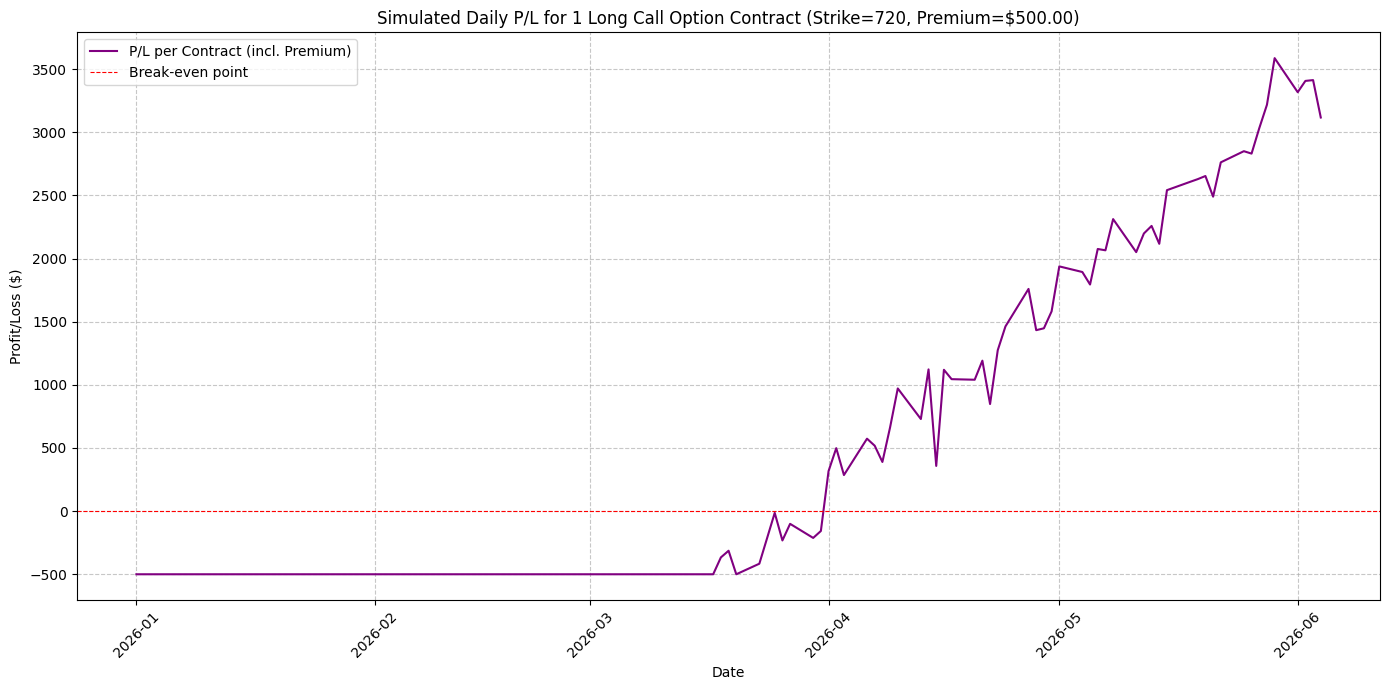

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(simulated_sp500_df['Date'], simulated_sp500_df['P/L per Contract'], label='P/L per Contract (incl. Premium)', color='purple')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8, label='Break-even point')
plt.title(f'Simulated Daily P/L for 1 Long Call Option Contract (Strike={strike_price}, Premium=${premium_per_contract:.2f})')
plt.xlabel('Date')
plt.ylabel('Profit/Loss ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Delta Hedging 1 Long Call Option to Replicate $1 Million SPY Exposure

This section simulates a delta hedging strategy. The goal is to dynamically adjust a position in SPY shares such that the overall portfolio (1 call option + SPY shares + cash) mimics the return of a direct $1 million investment in SPY.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- Black-Scholes Functions for Option Pricing and Greeks ---

def black_scholes_delta_call(S, K, T, r, sigma):
    """Calculates the Black-Scholes delta for a call option."""
    if T <= 0:
        # At expiration, delta is 1 if in-the-money (ITM), 0 if out-of-the-money (OTM)
        return 1.0 if S > K else 0.0

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

def black_scholes_call_price(S, K, T, r, sigma):
    """Calculates the Black-Scholes price for a call option."""
    if T <= 0:
        return max(0, S - K)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call_price = (S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2))
    return call_price

def black_scholes_gamma(S, K, T, r, sigma):
    """Calculates the Black-Scholes gamma for an option (same for call and put)."""
    if T <= 0:
        return 0.0 # Gamma approaches infinity at expiration, but for practical purposes in simulation, it's 0 after expiry.

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    return gamma

# --- Hedging Parameters ---
principal_target_exposure = 1_000_000 # The target amount to replicate in SPY
risk_free_rate = 0.02                 # Annual risk-free rate (e.g., U.S. Treasury bond yield)
volatility = 0.20                     # Annual volatility of SPY (a key assumption)
shares_per_contract = 100             # One option contract typically covers 100 shares

# Primary Call Option (the one we are hedging)
primary_option_strike = 720
option_expiration_date = pd.Timestamp('2026-06-04')
initial_primary_option_premium_per_contract = 500 # From previous step

# Secondary Call Option for Gamma Hedging (e.g., a higher strike OTM call)
# We'll assume we short this option to offset the long gamma of the primary option.
secondary_option_strike = 750 # Higher strike price
initial_secondary_option_premium_per_contract = 200 # Assumed premium for the gamma-hedging option (e.g. we receive this)


# --- Initialize the hedging portfolio's state (for Delta Hedging only) ---
# This section is for the previous delta hedging simulation, keep as is for comparison
portfolio_history = []
cash_balance = 0.0 # Tracks cash for transactions (buying/selling shares)
shares_held = 0.0  # Tracks the number of SPY shares held
option_value_held = 0.0 # Tracks the theoretical value of the call option
initial_portfolio_value = 0.0 # The starting value of our hedged portfolio for P/L calculation
prev_portfolio_value = None # To calculate daily P/L

# --- Simulate Delta Hedging Day by Day ---
for i, row in simulated_sp500_df.iterrows():
    current_date = row['Date']
    current_spy_price = row['SPY Price']

    # Calculate time to expiration (in years)
    time_to_exp_days = (option_expiration_date - current_date).days
    # Black-Scholes needs T > 0, so use a small positive number if T is 0, then apply expiration logic
    time_to_exp_bs = max(0.0001, time_to_exp_days / 365.25)

    # Calculate the primary call option's delta and theoretical value for the current day
    if time_to_exp_days <= 0: # On or after expiration
        current_call_delta = 1.0 if current_spy_price > primary_option_strike else 0.0
        current_option_value = max(0, (current_spy_price - primary_option_strike) * shares_per_contract)
    else:
        current_call_delta = black_scholes_delta_call(current_spy_price, primary_option_strike, time_to_exp_bs, risk_free_rate, volatility)
        current_option_value = black_scholes_call_price(current_spy_price, primary_option_strike, time_to_exp_bs, risk_free_rate, volatility) * shares_per_contract

    # --- Day 0: Initial Setup of the Hedged Portfolio ---
    if i == 0:
        # 1. Pay the premium for the primary call option contract
        cash_balance -= initial_primary_option_premium_per_contract
        option_value_held = current_option_value # Initialize with current theoretical option value

        # 2. Determine initial shares needed to match target SPY exposure
        # The total portfolio delta (primary option delta + stock delta) should equal the delta of $1M in SPY
        target_shares_for_hedging = (principal_target_exposure / current_spy_price) - (current_call_delta * shares_per_contract)

        # 3. Adjust cash balance for initial share purchase/sale
        cash_balance -= target_shares_for_hedging * current_spy_price
        shares_held = target_shares_for_hedging # Set initial shares held

        # 4. Calculate the initial total value of our hedged portfolio
        initial_portfolio_value = option_value_held + (shares_held * current_spy_price) + cash_balance
        prev_portfolio_value = initial_portfolio_value

    # --- Subsequent Days: Rebalancing the Hedge ---
    else:
        # 1. Calculate the new target shares for the current day
        target_shares_for_hedging = (principal_target_exposure / current_spy_price) - (current_call_delta * shares_per_contract)

        # 2. Calculate the change in shares needed (buy if positive, sell if negative)
        shares_to_adjust = target_shares_for_hedging - shares_held

        # 3. Adjust cash balance for these share transactions
        cash_balance -= shares_to_adjust * current_spy_price

        # 4. Update shares held and the option's theoretical value
        shares_held = target_shares_for_hedging
        option_value_held = current_option_value

    # Calculate current total portfolio value
    portfolio_value = option_value_held + (shares_held * current_spy_price) + cash_balance

    # Calculate daily P/L and cumulative P/L for the hedged portfolio
    daily_pnl = portfolio_value - prev_portfolio_value
    cumulative_pnl_hedged = portfolio_value - initial_portfolio_value
    prev_portfolio_value = portfolio_value # Update for next iteration

    # --- Calculate Benchmark P/L (direct $1M investment in SPY) ---
    initial_spy_price = simulated_sp500_df.loc[0, 'SPY Price']
    benchmark_shares = principal_target_exposure / initial_spy_price
    benchmark_current_value = benchmark_shares * current_spy_price
    benchmark_cumulative_pnl = benchmark_current_value - principal_target_exposure # P/L relative to initial $1M

    # Store daily results
    portfolio_history.append({
        'Date': current_date,
        'SPY Price': current_spy_price,
        'Call Delta': current_call_delta,
        'Shares Held': shares_held,
        'Option Value': current_option_value,
        'Cash Balance': cash_balance,
        'Portfolio Value': portfolio_value,
        'Daily P/L': daily_pnl,
        'Cumulative P/L (Hedged)': cumulative_pnl_hedged,
        'Benchmark Cumulative P/L': benchmark_cumulative_pnl
    })

delta_hedging_df = pd.DataFrame(portfolio_history)

print("Delta Hedging Simulation Results Head:")
display(delta_hedging_df.head())

print("\nDelta Hedging Simulation Results Tail:")
display(delta_hedging_df.tail())

Delta Hedging Simulation Results Head:


,Date,SPY Price,Call Delta,Shares Held,Option Value,Cash Balance,Portfolio Value,Daily P/L,Cumulative P/L (Hedged),Benchmark Cumulative P/L
0,2026-01-01,680.993428,0.382460,1430.196972,2199.149043,-974454.739141,1699.149043,0.000000,0.000000,0.000000
1,2026-01-02,680.450744,0.379419,1431.672196,2166.221092,-975458.556652,890.075820,-809.073224,-809.073224,-796.900761
2,2026-01-05,682.749923,0.387322,1425.932971,2217.243802,-971540.100774,4232.768327,3342.692508,2533.619284,2579.311564
3,2026-01-06,685.227878,0.397523,1419.616187,2301.886403,-967211.664414,7850.809182,3618.040855,6151.660139,6218.047653
4,2026-01-07,682.440784,0.384565,1426.872086,2180.282928,-972163.385760,3772.602326,-4078.206856,2073.453283,2125.359502



Delta Hedging Simulation Results Tail:


,Date,SPY Price,Call Delta,Shares Held,Option Value,Cash Balance,Portfolio Value,Daily P/L,Cumulative P/L (Hedged),Benchmark Cumulative P/L
106,2026-05-29,760.863281,0.985340,1215.762599,4120.176087,-818401.805302,110747.490424,4866.764964,109048.341381,117284.322091
107,2026-06-01,758.167337,0.997933,1219.176686,3829.395689,-820990.255109,107179.082812,-3568.407612,105479.933769,113325.482934
108,2026-06-02,759.060555,0.999831,1217.434834,3913.987063,-819668.083869,108352.664604,1173.581792,106653.515561,114637.122439
109,2026-06-03,759.123835,1.000000,1217.308150,3916.325971,-819571.914857,108432.042928,79.378324,106732.893885,114730.045677
110,2026-06-04,756.162458,1.000000,1222.467137,3616.245757,-823472.946705,104527.053295,-3904.989633,102827.904252,110381.431213


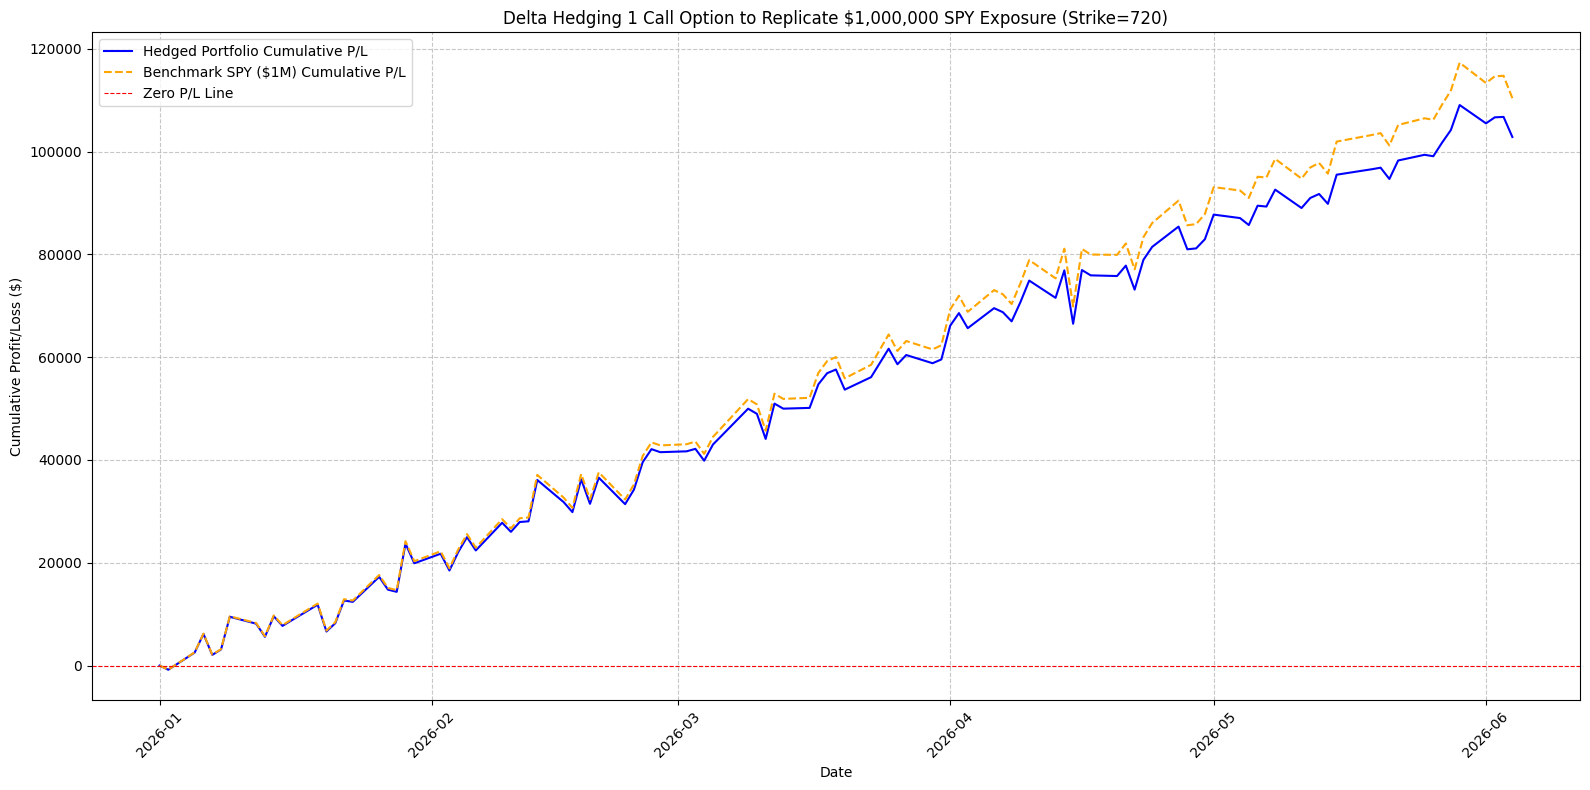

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(delta_hedging_df['Date'], delta_hedging_df['Cumulative P/L (Hedged)'], label='Hedged Portfolio Cumulative P/L', color='blue')
plt.plot(delta_hedging_df['Date'], delta_hedging_df['Benchmark Cumulative P/L'], label='Benchmark SPY ($1M) Cumulative P/L', color='orange', linestyle='--')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8, label='Zero P/L Line')
plt.title(f'Delta Hedging 1 Call Option to Replicate ${principal_target_exposure:,.0f} SPY Exposure (Strike={option_strike})')
plt.xlabel('Date')
plt.ylabel('Cumulative Profit/Loss ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Gamma Hedging: Achieving Gamma Neutrality with a Second Option

As we observed, delta hedging alone can leave the portfolio exposed to price changes in the underlying asset, particularly when the option's delta changes rapidly. This sensitivity of delta to changes in the underlying price is called **gamma**.

To create a truly robust hedge, especially for options with significant time to expiration, we can aim for **gamma neutrality**. This means ensuring that the overall portfolio's gamma is close to zero, making the portfolio less sensitive to changes in the underlying asset's price and thus keeping the delta hedge more stable.

We achieve gamma neutrality by introducing a second option position (e.g., buying or selling another option with a different strike price or expiration date) and dynamically adjusting its quantity alongside the underlying shares. The goal is to offset the gamma of the primary option with the gamma of the secondary option.

Let's implement a gamma hedging strategy using a second call option (e.g., a short call with a higher strike) to neutralize the portfolio's gamma.

In [ ]:
# --- Initialize the hedging portfolio's state for Delta-Gamma Hedging ---
portfolio_history_gamma = []
cash_balance_gamma = 0.0
shares_held_gamma = 0.0
primary_option_value_held = 0.0
secondary_option_contracts_held = 0.0
secondary_option_value_held = 0.0

initial_portfolio_value_gamma = 0.0
prev_portfolio_value_gamma = None

# --- Simulate Delta-Gamma Hedging Day by Day ---
for i, row in simulated_sp500_df.iterrows():
    current_date = row['Date']
    current_spy_price = row['SPY Price']

    # Calculate time to expiration (in years)
    time_to_exp_days = (option_expiration_date - current_date).days
    time_to_exp_bs = max(0.0001, time_to_exp_days / 365.25)

    # --- Calculate Greeks and Prices for Primary Option (Long Call) ---
    if time_to_exp_days <= 0:
        primary_call_delta = 1.0 if current_spy_price > primary_option_strike else 0.0
        primary_call_gamma = 0.0
        primary_option_current_value = max(0, (current_spy_price - primary_option_strike) * shares_per_contract)
    else:
        primary_call_delta = black_scholes_delta_call(current_spy_price, primary_option_strike, time_to_exp_bs, risk_free_rate, volatility)
        primary_call_gamma = black_scholes_gamma(current_spy_price, primary_option_strike, time_to_exp_bs, risk_free_rate, volatility)
        primary_option_current_value = black_scholes_call_price(current_spy_price, primary_option_strike, time_to_exp_bs, risk_free_rate, volatility) * shares_per_contract

    # --- Calculate Greeks and Prices for Secondary Option (Short Call) ---
    if time_to_exp_days <= 0:
        secondary_call_delta = 1.0 if current_spy_price > secondary_option_strike else 0.0
        secondary_call_gamma = 0.0
        secondary_option_current_value = max(0, (current_spy_price - secondary_option_strike) * shares_per_contract)
    else:
        secondary_call_delta = black_scholes_delta_call(current_spy_price, secondary_option_strike, time_to_exp_bs, risk_free_rate, volatility)
        secondary_call_gamma = black_scholes_gamma(current_spy_price, secondary_option_strike, time_to_exp_bs, risk_free_rate, volatility)
        secondary_option_current_value = black_scholes_call_price(current_spy_price, secondary_option_strike, time_to_exp_bs, risk_free_rate, volatility) * shares_per_contract

    # --- Day 0: Initial Setup for Delta-Gamma Hedging ---
    if i == 0:
        # 1. Pay/Receive premiums for options
        cash_balance_gamma -= initial_primary_option_premium_per_contract # Pay for primary
        cash_balance_gamma += initial_secondary_option_premium_per_contract # Receive for secondary (short)

        primary_option_value_held = primary_option_current_value
        secondary_option_value_held = 0 # Will be set once contracts are determined

        # 2. Determine initial secondary option contracts for gamma neutrality
        # Portfolio Gamma = (Gamma Primary Option * Contracts Primary) + (Gamma Secondary Option * Contracts Secondary) + (Gamma Shares * Shares)
        # We are long 1 primary option contract, shares have 0 gamma
        # Target Gamma = 0 => (primary_call_gamma * shares_per_contract * 1) + (secondary_call_gamma * shares_per_contract * X) = 0
        # X = - (primary_call_gamma / secondary_call_gamma)
        if secondary_call_gamma != 0:
            secondary_option_contracts_to_hold = - (primary_call_gamma / secondary_call_gamma)
        else:
            secondary_option_contracts_to_hold = 0 # Avoid division by zero, or if both gammas are zero

        secondary_option_contracts_held = secondary_option_contracts_to_hold
        # Adjust cash for initial secondary option position
        cash_balance_gamma -= secondary_option_contracts_held * secondary_option_current_value
        secondary_option_value_held = secondary_option_contracts_held * secondary_option_current_value

        # 3. Determine initial shares needed for delta neutrality
        # Target Delta (from $1M SPY exposure) = Delta Shares + Delta Primary Option + Delta Secondary Option
        target_delta_exposure = (principal_target_exposure / current_spy_price)
        portfolio_delta = (primary_call_delta * shares_per_contract) + (secondary_call_delta * shares_per_contract * secondary_option_contracts_held)
        shares_to_hold = target_delta_exposure - portfolio_delta

        cash_balance_gamma -= shares_to_hold * current_spy_price
        shares_held_gamma = shares_to_hold

        # 4. Calculate initial portfolio value
        initial_portfolio_value_gamma = primary_option_value_held + secondary_option_value_held + (shares_held_gamma * current_spy_price) + cash_balance_gamma
        prev_portfolio_value_gamma = initial_portfolio_value_gamma

    # --- Subsequent Days: Rebalancing the Delta-Gamma Hedge ---
    else:
        # Rebalance gamma first to determine secondary option contracts
        if secondary_call_gamma != 0:
            secondary_option_contracts_to_hold = - (primary_call_gamma / secondary_call_gamma)
        else:
            secondary_option_contracts_to_hold = 0

        # Adjust cash for secondary option transactions
        change_in_secondary_contracts = secondary_option_contracts_to_hold - secondary_option_contracts_held
        cash_balance_gamma -= change_in_secondary_contracts * secondary_option_current_value
        secondary_option_contracts_held = secondary_option_contracts_to_hold

        # Then rebalance delta
        target_delta_exposure = (principal_target_exposure / current_spy_price)
        portfolio_delta = (primary_call_delta * shares_per_contract) + (secondary_call_delta * shares_per_contract * secondary_option_contracts_held)
        shares_to_hold = target_delta_exposure - portfolio_delta

        change_in_shares = shares_to_hold - shares_held_gamma
        cash_balance_gamma -= change_in_shares * current_spy_price
        shares_held_gamma = shares_to_hold

        # Update option values for current day
        primary_option_value_held = primary_option_current_value
        secondary_option_value_held = secondary_option_contracts_held * secondary_option_current_value

    # Calculate current total portfolio value
    portfolio_value_gamma = primary_option_value_held + secondary_option_value_held + (shares_held_gamma * current_spy_price) + cash_balance_gamma

    # Calculate daily P/L and cumulative P/L for the gamma-hedged portfolio
    daily_pnl_gamma = portfolio_value_gamma - prev_portfolio_value_gamma
    cumulative_pnl_gamma_hedged = portfolio_value_gamma - initial_portfolio_value_gamma
    prev_portfolio_value_gamma = portfolio_value_gamma

    # --- Calculate Benchmark P/L (direct $1M investment in SPY) ---
    initial_spy_price = simulated_sp500_df.loc[0, 'SPY Price']
    benchmark_shares = principal_target_exposure / initial_spy_price
    benchmark_current_value = benchmark_shares * current_spy_price
    benchmark_cumulative_pnl = benchmark_current_value - principal_target_exposure # P/L relative to initial $1M

    # Store daily results
    portfolio_history_gamma.append({
        'Date': current_date,
        'SPY Price': current_spy_price,
        'Primary Call Delta': primary_call_delta,
        'Primary Call Gamma': primary_call_gamma,
        'Secondary Call Delta': secondary_call_delta,
        'Secondary Call Gamma': secondary_call_gamma,
        'Secondary Option Contracts': secondary_option_contracts_held,
        'Shares Held': shares_held_gamma,
        'Primary Option Value': primary_option_value_held,
        'Secondary Option Value': secondary_option_value_held,
        'Cash Balance': cash_balance_gamma,
        'Portfolio Value': portfolio_value_gamma,
        'Daily P/L': daily_pnl_gamma,
        'Cumulative P/L (Gamma Hedged)': cumulative_pnl_gamma_hedged,
        'Benchmark Cumulative P/L': benchmark_cumulative_pnl
    })

gamma_hedging_df = pd.DataFrame(portfolio_history_gamma)

print("Delta-Gamma Hedging Simulation Results Head:")
display(gamma_hedging_df.head())

print("\nDelta-Gamma Hedging Simulation Results Tail:")
display(gamma_hedging_df.tail())

Delta-Gamma Hedging Simulation Results Head:


,Date,SPY Price,Primary Call Delta,Primary Call Gamma,Secondary Call Delta,Secondary Call Gamma,Secondary Option Contracts,Shares Held,Primary Option Value,Secondary Option Value,Cash Balance,Portfolio Value,Daily P/L,Cumulative P/L (Gamma Hedged),Benchmark Cumulative P/L
0,2026-01-01,680.993428,0.382460,0.004314,0.269817,0.003737,-1.154192,1461.339045,2199.149043,-1579.036572,-993883.249877,1899.149043,0.000000,0.000000,0.000000
1,2026-01-02,680.450744,0.379419,0.004321,0.266849,0.003732,-1.157829,1462.568700,2166.221092,-1555.108354,-994715.084092,1101.988942,-797.160102,-797.160102,-796.900761
2,2026-01-05,682.749923,0.387322,0.004376,0.272653,0.003797,-1.152475,1457.355501,2217.243802,-1583.058897,-991163.127903,4480.412689,3378.423748,2581.263646,2579.311564
3,2026-01-06,685.227878,0.397523,0.004407,0.281182,0.003854,-1.143479,1451.768780,2301.886403,-1636.857946,-987347.828486,8109.639949,3629.227260,6210.490906,6218.047653
4,2026-01-07,682.440784,0.384565,0.004398,0.269555,0.003803,-1.156643,1458.049928,2180.282928,-1554.492291,-991616.647623,4041.879052,-4067.760897,2142.730009,2125.359502



Delta-Gamma Hedging Simulation Results Tail:


,Date,SPY Price,Primary Call Delta,Primary Call Gamma,Secondary Call Delta,Secondary Call Gamma,Secondary Option Contracts,Shares Held,Primary Option Value,Secondary Option Value,Cash Balance,Portfolio Value,Daily P/L,Cumulative P/L (Gamma Hedged),Benchmark Cumulative P/L
106,2026-05-29,760.863281,0.985340,1.903828e-03,0.721275,0.017221,-0.110551,1223.736384,4120.176087,-160.480428,-821606.737427,113449.037979,4875.387006,111549.888936,117284.322091
107,2026-06-01,758.167337,0.997933,4.752665e-04,0.730944,0.024018,-0.019788,1220.623062,3829.395689,-20.917795,-819342.265224,109902.749492,-3546.288487,108003.600449,113325.482934
108,2026-06-02,759.060555,0.999831,5.758561e-05,0.795654,0.025244,-0.002281,1217.616335,3913.987063,-2.381754,-817078.256447,111077.880595,1175.131103,109178.731552,114637.122439
109,2026-06-03,759.123835,1.000000,1.337282e-07,0.878177,0.025450,-0.000005,1217.308612,3916.325971,-0.005068,-816846.850988,111157.452027,79.571432,109258.302984,114730.045677
110,2026-06-04,756.162458,1.000000,0.000000e+00,1.000000,0.000000,0.000000,1222.467137,3616.245757,0.000000,-820747.537143,107252.462857,-3904.989170,105353.313814,110381.431213


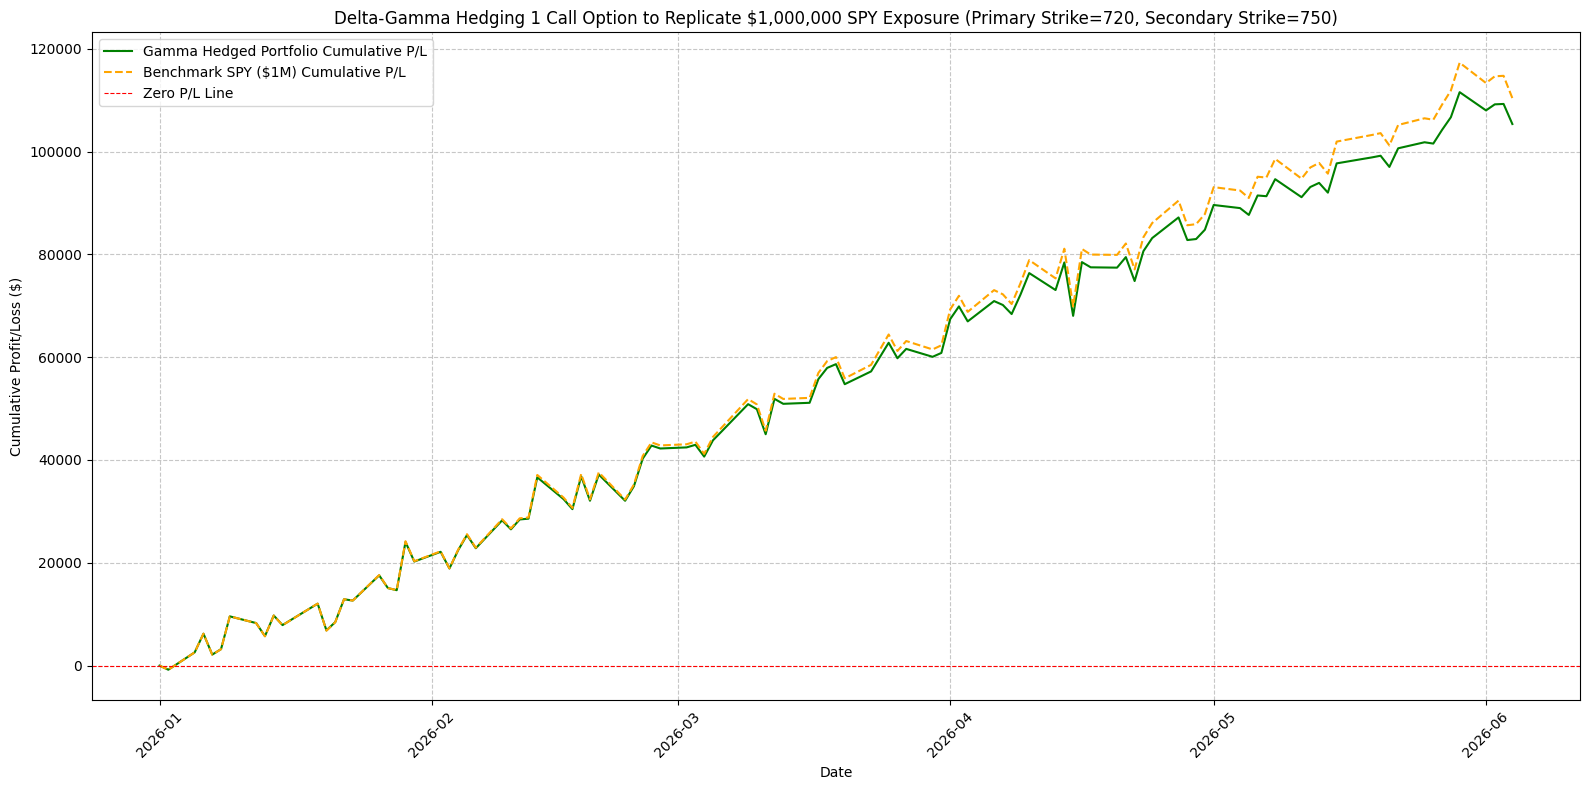

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(gamma_hedging_df['Date'], gamma_hedging_df['Cumulative P/L (Gamma Hedged)'], label='Gamma Hedged Portfolio Cumulative P/L', color='green')
plt.plot(gamma_hedging_df['Date'], gamma_hedging_df['Benchmark Cumulative P/L'], label='Benchmark SPY ($1M) Cumulative P/L', color='orange', linestyle='--')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8, label='Zero P/L Line')
plt.title(f'Delta-Gamma Hedging 1 Call Option to Replicate ${principal_target_exposure:,.0f} SPY Exposure (Primary Strike={primary_option_strike}, Secondary Strike={secondary_option_strike})')
plt.xlabel('Date')
plt.ylabel('Cumulative Profit/Loss ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Scenario: SPY Price Drops (680 to 600)

Now, let's consider a bearish scenario where the S&P 500 index (and thus SPY) drops significantly over the same period. We'll simulate a drop from an initial SPY price of 680 to a final SPY price of 600.

In [ ]:
# Define the date range (same as before)
start_date = '2026-01-01'
end_date = '2026-06-04'
date_range = pd.date_range(start=start_date, end=end_date, freq='B') # 'B' for business days

# Define start and end prices for the dropping scenario (SPY * 10)
start_price_drop = 6800
end_price_drop = 6000

# Generate a linear trend for the drop
linear_prices_drop = np.linspace(start_price_drop, end_price_drop, len(date_range))

# Add some random noise
np.random.seed(43) # Use a different seed for a different noise pattern
noise_drop = np.random.normal(0, 15, len(date_range)) # Slightly less noise for a clearer trend
simulated_prices_drop = linear_prices_drop + noise_drop

# Create a new DataFrame for the dropping scenario
simulated_sp500_df_drop = pd.DataFrame({
    'Date': date_range,
    'Closing Price': simulated_prices_drop
})

# Calculate approximate SPY price from simulated S&P 500 index
simulated_sp500_df_drop['SPY Price'] = simulated_sp500_df_drop['Closing Price'] / 10

print("Simulated S&P 500 (Dropping Scenario) Data Head:")
display(simulated_sp500_df_drop.head())

print("\nSimulated S&P 500 (Dropping Scenario) Data Tail:")
display(simulated_sp500_df_drop.tail())

Simulated S&P 500 (Dropping Scenario) Data Head:


,Date,Closing Price,SPY Price
0,2026-01-01,6803.860999,680.386100
1,2026-01-02,6779.100051,677.910005
2,2026-01-05,6779.776999,677.977700
3,2026-01-06,6770.158084,677.015808
4,2026-01-07,6783.780191,678.378019



Simulated S&P 500 (Dropping Scenario) Data Tail:


,Date,Closing Price,SPY Price
106,2026-05-29,5983.704811,598.370481
107,2026-06-01,6003.133788,600.313379
108,2026-06-02,5983.284862,598.328486
109,2026-06-03,6008.834552,600.883455
110,2026-06-04,5997.746498,599.774650


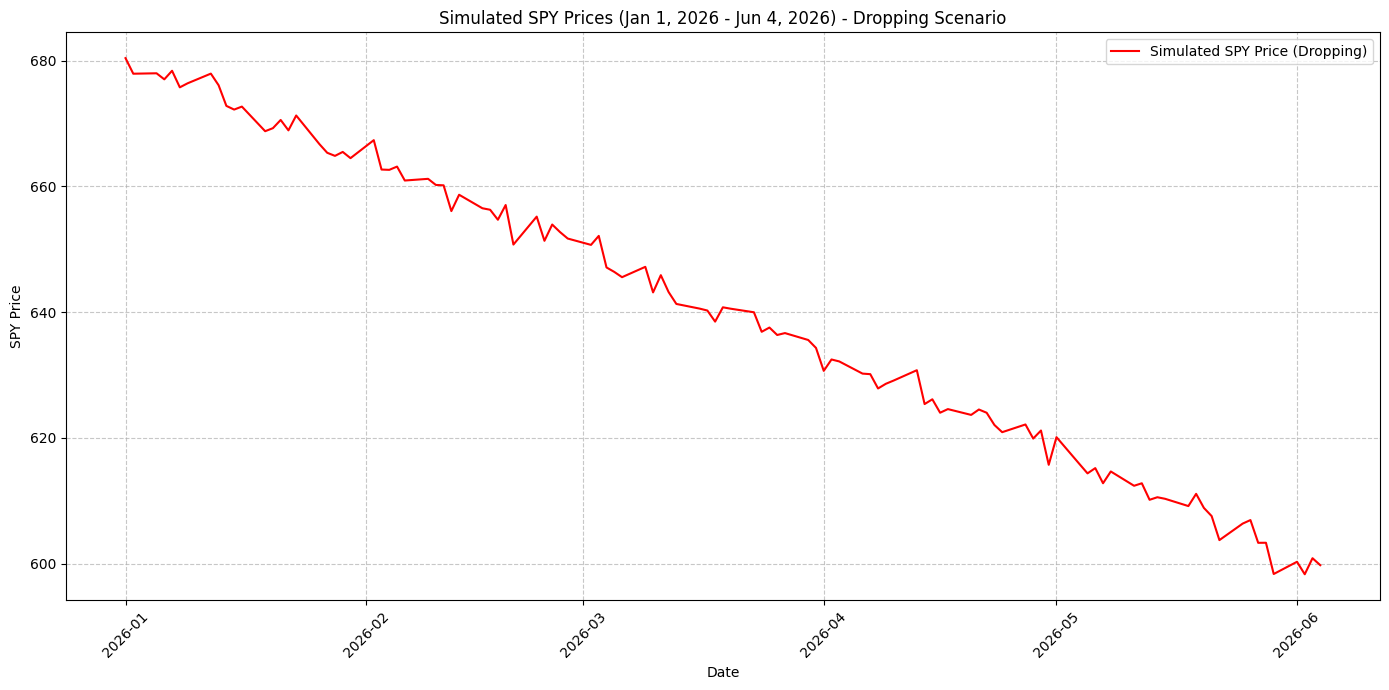

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(simulated_sp500_df_drop['Date'], simulated_sp500_df_drop['SPY Price'], label='Simulated SPY Price (Dropping)', color='red')
plt.title('Simulated SPY Prices (Jan 1, 2026 - Jun 4, 2026) - Dropping Scenario')
plt.xlabel('Date')
plt.ylabel('SPY Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Delta Hedging Simulation with Dropping SPY Prices

Now, let's run the delta hedging simulation using this new `simulated_sp500_df_drop` DataFrame.

In [ ]:
# --- Initialize the hedging portfolio's state for Delta Hedging (Dropping Scenario) ---
portfolio_history_drop = []
cash_balance_drop = 0.0 # Tracks cash for transactions (buying/selling shares)
shares_held_drop = 0.0  # Tracks the number of SPY shares held
option_value_held_drop = 0.0 # Tracks the theoretical value of the call option
initial_portfolio_value_drop = 0.0 # The starting value of our hedged portfolio for P/L calculation
prev_portfolio_value_drop = None # To calculate daily P/L

# --- Simulate Delta Hedging Day by Day (Dropping Scenario) ---
for i, row in simulated_sp500_df_drop.iterrows():
    current_date = row['Date']
    current_spy_price = row['SPY Price']

    # Calculate time to expiration (in years)
    time_to_exp_days = (option_expiration_date - current_date).days
    time_to_exp_bs = max(0.0001, time_to_exp_days / 365.25)

    # Calculate the primary call option's delta and theoretical value for the current day
    if time_to_exp_days <= 0: # On or after expiration
        current_call_delta_drop = 1.0 if current_spy_price > primary_option_strike else 0.0
        current_option_value_drop = max(0, (current_spy_price - primary_option_strike) * shares_per_contract)
    else:
        current_call_delta_drop = black_scholes_delta_call(current_spy_price, primary_option_strike, time_to_exp_bs, risk_free_rate, volatility)
        current_option_value_drop = black_scholes_call_price(current_spy_price, primary_option_strike, time_to_exp_bs, risk_free_rate, volatility) * shares_per_contract

    # --- Day 0: Initial Setup of the Hedged Portfolio ---
    if i == 0:
        # 1. Pay the premium for the primary call option contract
        cash_balance_drop -= initial_primary_option_premium_per_contract
        option_value_held_drop = current_option_value_drop # Initialize with current theoretical option value

        # 2. Determine initial shares needed to match target SPY exposure
        target_shares_for_hedging_drop = (principal_target_exposure / current_spy_price) - (current_call_delta_drop * shares_per_contract)

        # 3. Adjust cash balance for initial share purchase/sale
        cash_balance_drop -= target_shares_for_hedging_drop * current_spy_price
        shares_held_drop = target_shares_for_hedging_drop # Set initial shares held

        # 4. Calculate the initial total value of our hedged portfolio
        initial_portfolio_value_drop = option_value_held_drop + (shares_held_drop * current_spy_price) + cash_balance_drop
        prev_portfolio_value_drop = initial_portfolio_value_drop

    # --- Subsequent Days: Rebalancing the Hedge ---
    else:
        # 1. Calculate the new target shares for the current day
        target_shares_for_hedging_drop = (principal_target_exposure / current_spy_price) - (current_call_delta_drop * shares_per_contract)

        # 2. Calculate the change in shares needed (buy if positive, sell if negative)
        shares_to_adjust_drop = target_shares_for_hedging_drop - shares_held_drop

        # 3. Adjust cash balance for these share transactions
        cash_balance_drop -= shares_to_adjust_drop * current_spy_price

        # 4. Update shares held and the option's theoretical value
        shares_held_drop = target_shares_for_hedging_drop
        option_value_held_drop = current_option_value_drop

    # Calculate current total portfolio value
    portfolio_value_drop = option_value_held_drop + (shares_held_drop * current_spy_price) + cash_balance_drop

    # Calculate daily P/L and cumulative P/L for the hedged portfolio
    daily_pnl_drop = portfolio_value_drop - prev_portfolio_value_drop
    cumulative_pnl_hedged_drop = portfolio_value_drop - initial_portfolio_value_drop
    prev_portfolio_value_drop = portfolio_value_drop # Update for next iteration

    # --- Calculate Benchmark P/L (direct $1M investment in SPY) ---
    initial_spy_price_drop = simulated_sp500_df_drop.loc[0, 'SPY Price']
    benchmark_shares_drop = principal_target_exposure / initial_spy_price_drop
    benchmark_current_value_drop = benchmark_shares_drop * current_spy_price
    benchmark_cumulative_pnl_drop = benchmark_current_value_drop - principal_target_exposure # P/L relative to initial $1M

    # Store daily results
    portfolio_history_drop.append({
        'Date': current_date,
        'SPY Price': current_spy_price,
        'Call Delta': current_call_delta_drop,
        'Shares Held': shares_held_drop,
        'Option Value': current_option_value_drop,
        'Cash Balance': cash_balance_drop,
        'Portfolio Value': portfolio_value_drop,
        'Daily P/L': daily_pnl_drop,
        'Cumulative P/L (Hedged)': cumulative_pnl_hedged_drop,
        'Benchmark Cumulative P/L': benchmark_cumulative_pnl_drop
    })

delta_hedging_df_drop = pd.DataFrame(portfolio_history_drop)

print("Delta Hedging Simulation Results (Dropping Scenario) Head:")
display(delta_hedging_df_drop.head())

print("\nDelta Hedging Simulation Results (Dropping Scenario) Tail:")
display(delta_hedging_df_drop.tail())

Delta Hedging Simulation Results (Dropping Scenario) Head:


,Date,SPY Price,Call Delta,Shares Held,Option Value,Cash Balance,Portfolio Value,Daily P/L,Cumulative P/L (Hedged),Benchmark Cumulative P/L
0,2026-01-01,680.386100,0.379841,1431.769571,2176.000698,-974656.114028,1676.000698,0.000000,0.000000,0.000000
1,2026-01-02,677.910005,0.368470,1438.275008,2071.212791,-979066.215104,-1973.984347,-3649.985044,-3649.985044,-3639.249486
2,2026-01-05,677.977700,0.366539,1438.320860,2037.372659,-979097.301947,-1910.460793,63.523553,-3586.461491,-3539.754857
3,2026-01-06,677.015808,0.361614,1440.908990,1990.223511,-980849.506963,-3341.118502,-1430.657709,-5017.119200,-4953.498416
4,2026-01-07,678.378019,0.366772,1437.427135,2027.662903,-978487.492661,-1340.857480,2000.261022,-3016.858178,-2951.384190



Delta Hedging Simulation Results (Dropping Scenario) Tail:


,Date,SPY Price,Call Delta,Shares Held,Option Value,Cash Balance,Portfolio Value,Daily P/L,Cumulative P/L (Hedged),Benchmark Cumulative P/L
106,2026-05-29,598.370481,3.168094e-13,1671.205435,6.494709e-11,-1.127033e+06,-127032.713578,-8234.760036,-128708.714276,-120542.760650
107,2026-06-01,600.313379,6.764687e-24,1665.796624,7.199533e-22,-1.123786e+06,-123785.732304,3246.981274,-125461.733002,-117687.179463
108,2026-06-02,598.328486,4.072880e-36,1671.322732,2.847665e-34,-1.127092e+06,-127092.159696,-3306.427392,-128768.160394,-120604.482740
109,2026-06-03,600.883455,3.879523e-67,1664.216233,1.402324e-65,-1.122822e+06,-122821.982012,4270.177684,-124497.982710,-116849.307628
110,2026-06-04,599.774650,0.000000e+00,1667.292875,0.000000e+00,-1.124667e+06,-124667.274021,-1845.292008,-126343.274718,-118478.978542


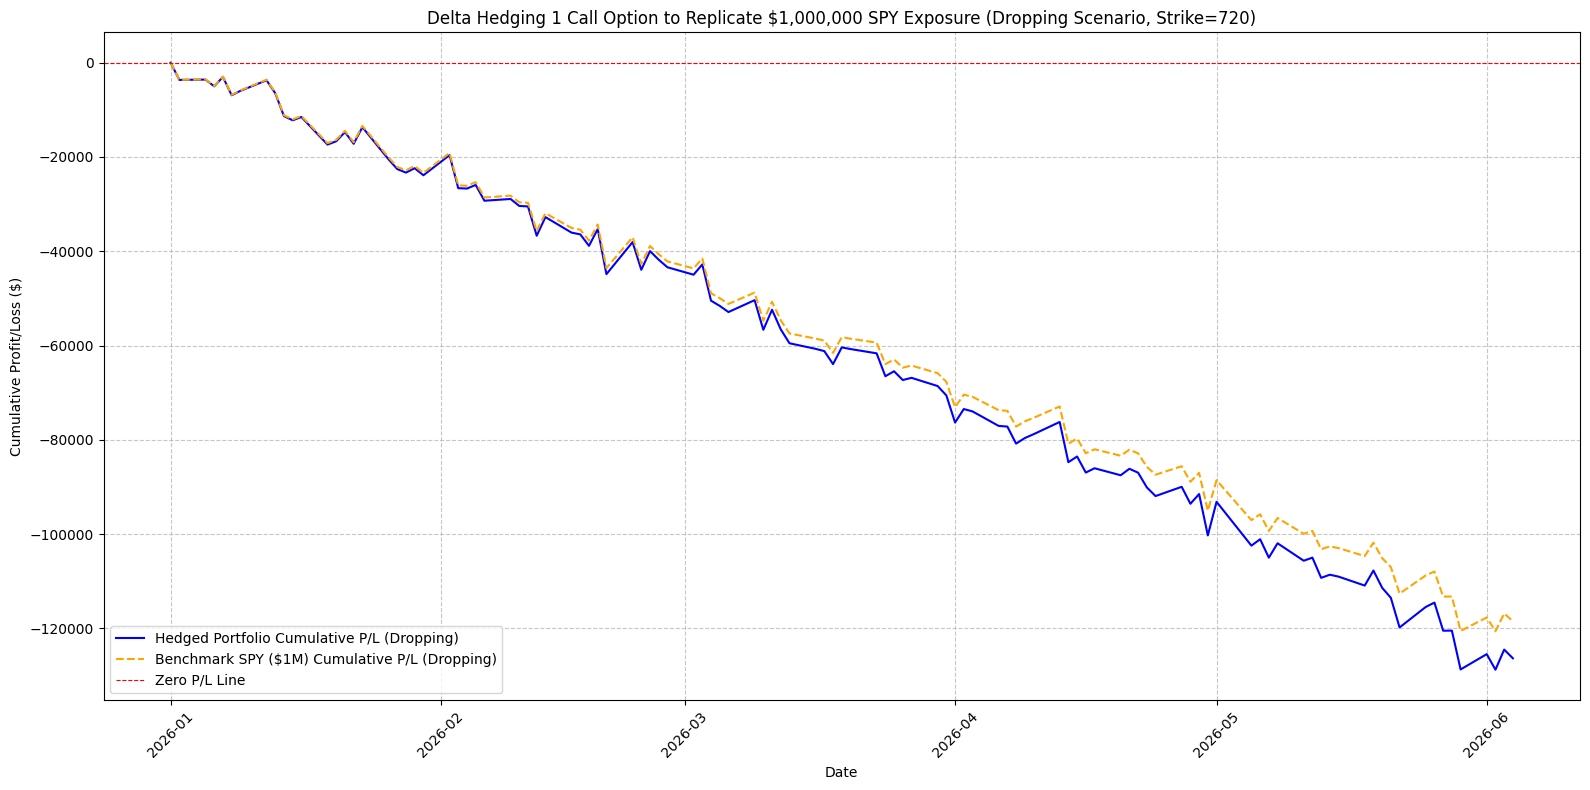

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(delta_hedging_df_drop['Date'], delta_hedging_df_drop['Cumulative P/L (Hedged)'], label='Hedged Portfolio Cumulative P/L (Dropping)', color='blue')
plt.plot(delta_hedging_df_drop['Date'], delta_hedging_df_drop['Benchmark Cumulative P/L'], label='Benchmark SPY ($1M) Cumulative P/L (Dropping)', color='orange', linestyle='--')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8, label='Zero P/L Line')
plt.title(f'Delta Hedging 1 Call Option to Replicate ${principal_target_exposure:,.0f} SPY Exposure (Dropping Scenario, Strike={primary_option_strike})')
plt.xlabel('Date')
plt.ylabel('Cumulative Profit/Loss ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()